## 1. Import Data and EDA

Descriptions of the columns are available [here](./Data/floods_description.md)

In [1]:
import geopandas as gpd

df = gpd.read_file('./Data/floods.gpkg')

df.head()

,ward,subcounty,county,pop2009,flooded,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,slope_mean_deg,geometry
0,WABERA,Isiolo Sub County,ISIOLO,17431.0,0,0.000000,0.000000,0.000000,1099.219448,1026.0,1177.0,1.413028,"MULTIPOLYGON (((37.59968 0.40029, 37.59976 0.4..."
1,North Kamagambo Ward,Rongo Sub County,Migori,18755.0,0,258.608840,14.135786,39.955728,1405.549444,1350.0,1508.0,2.246821,"MULTIPOLYGON (((34.59938 -0.65054, 34.60006 -0..."
2,Central Kamagambo Ward,Rongo Sub County,Migori,27756.0,0,125.951383,8.779010,20.537484,1462.532567,1387.0,1534.0,3.392240,"MULTIPOLYGON (((34.61175 -0.73357, 34.61183 -0..."
3,South Kamagambo Ward,Rongo Sub County,Migori,27179.0,0,45.941367,5.696220,10.762588,1490.546337,1363.0,1638.0,4.263301,"MULTIPOLYGON (((34.61751 -0.87293, 34.6175 -0...."
4,North Sakwa Ward,Awendo Sub County,Migori,22874.0,0,78.351185,4.580237,10.795914,1376.935386,1287.0,1617.0,3.834336,"MULTIPOLYGON (((34.55349 -0.75193, 34.55364 -0..."


In [2]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ward                 1450 non-null   object  
 1   subcounty            1450 non-null   object  
 2   county               1450 non-null   object  
 3   pop2009              1450 non-null   float64 
 4   flooded              1450 non-null   int64   
 5   rain_cumulative_mm   1450 non-null   float64 
 6   rain_max_daily_mm    1450 non-null   float64 
 7   rain_preflood_7d_mm  1450 non-null   float64 
 8   elevation_mean_m     1450 non-null   float64 
 9   elevation_min_m      1450 non-null   float64 
 10  elevation_max_m      1450 non-null   float64 
 11  slope_mean_deg       1450 non-null   float64 
 12  geometry             1450 non-null   geometry
dtypes: float64(8), geometry(1), int64(1), object(3)
memory usage: 147.4+ KB


In [3]:
df.duplicated().sum()

0

## 2. Create features and target

I will engineer a new feature: `elevation_range_m`, that is the difference between the maximum (`elevation_max_m`) and minimum (`elevation_min_m`) elevations. Thi is important because places with steeper slopes i.e. greater elevation ranges tend to flood less compared to flat areas with lower eleation ranges.

In [4]:
df['elevation_range_m'] = df['elevation_max_m'] - df['elevation_min_m']

df.head()

,ward,subcounty,county,pop2009,flooded,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,slope_mean_deg,geometry,elevation_range_m
0,WABERA,Isiolo Sub County,ISIOLO,17431.0,0,0.000000,0.000000,0.000000,1099.219448,1026.0,1177.0,1.413028,"MULTIPOLYGON (((37.59968 0.40029, 37.59976 0.4...",151.0
1,North Kamagambo Ward,Rongo Sub County,Migori,18755.0,0,258.608840,14.135786,39.955728,1405.549444,1350.0,1508.0,2.246821,"MULTIPOLYGON (((34.59938 -0.65054, 34.60006 -0...",158.0
2,Central Kamagambo Ward,Rongo Sub County,Migori,27756.0,0,125.951383,8.779010,20.537484,1462.532567,1387.0,1534.0,3.392240,"MULTIPOLYGON (((34.61175 -0.73357, 34.61183 -0...",147.0
3,South Kamagambo Ward,Rongo Sub County,Migori,27179.0,0,45.941367,5.696220,10.762588,1490.546337,1363.0,1638.0,4.263301,"MULTIPOLYGON (((34.61751 -0.87293, 34.6175 -0....",275.0
4,North Sakwa Ward,Awendo Sub County,Migori,22874.0,0,78.351185,4.580237,10.795914,1376.935386,1287.0,1617.0,3.834336,"MULTIPOLYGON (((34.55349 -0.75193, 34.55364 -0...",330.0


In [5]:
df.columns

Index(['ward', 'subcounty', 'county', 'pop2009', 'flooded',
       'rain_cumulative_mm', 'rain_max_daily_mm', 'rain_preflood_7d_mm',
       'elevation_mean_m', 'elevation_min_m', 'elevation_max_m',
       'slope_mean_deg', 'geometry', 'elevation_range_m'],
      dtype='object')

In [6]:
# Drop geometry and metadata columns
feature_columns = [
    'pop2009',
    'rain_cumulative_mm',
    'rain_max_daily_mm',
    'rain_preflood_7d_mm',
    'elevation_mean_m',
    'elevation_min_m',
    'elevation_max_m',
    'elevation_range_m',
    'slope_mean_deg'
]

target_column = 'flooded'

# Features
X = df[feature_columns]
y = df[target_column]

X.head()

,pop2009,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,elevation_range_m,slope_mean_deg
0,17431.0,0.000000,0.000000,0.000000,1099.219448,1026.0,1177.0,151.0,1.413028
1,18755.0,258.608840,14.135786,39.955728,1405.549444,1350.0,1508.0,158.0,2.246821
2,27756.0,125.951383,8.779010,20.537484,1462.532567,1387.0,1534.0,147.0,3.392240
3,27179.0,45.941367,5.696220,10.762588,1490.546337,1363.0,1638.0,275.0,4.263301
4,22874.0,78.351185,4.580237,10.795914,1376.935386,1287.0,1617.0,330.0,3.834336


## 3. Preprocessing

First perform standard **train-test split**

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2026, stratify=y, test_size=0.3)

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1015 entries, 454 to 845
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pop2009              1015 non-null   float64
 1   rain_cumulative_mm   1015 non-null   float64
 2   rain_max_daily_mm    1015 non-null   float64
 3   rain_preflood_7d_mm  1015 non-null   float64
 4   elevation_mean_m     1015 non-null   float64
 5   elevation_min_m      1015 non-null   float64
 6   elevation_max_m      1015 non-null   float64
 7   elevation_range_m    1015 non-null   float64
 8   slope_mean_deg       1015 non-null   float64
dtypes: float64(9)
memory usage: 79.3 KB


For neural networks, standardization of the features and targets has to be done.

`y` is a binary column. Thus, it does not need to be standardized

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape

(1015, 9)

Due to the limited size of the dataset, we will not have validation data.

## 4. Modelling

I will use Keras' API to build the ANN.

I will ensure I use a balanced class weight to account for class imbalance

I will experiment with three types of regularization to see which results in the best metrics:
 - l1 regularization
 - l2 regularization
 - dropout regularization

I will also build a model that implements **Early Stopping**

I will start by building a baseline model that has no regularization whatsoever

In [9]:
# Computing class weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_dict = dict(enumerate(class_weights))

class_dict

{0: 0.6342957130358705, 1: 2.3615635179153096}

In [ ]:
# Baseline model
import keras
from keras import models, layers

# Instantiate
baseline_model = models.Sequential()
input_shape = (X_train_scaled.shape[1],)

# Add input layer
baseline_model.add(layers.Input(input_shape))

# Add hidden layers
baseline_model.add(layers.Dense(50, activation='relu'))
baseline_model.add(layers.Dense(25, activation='relu'))

# Add output layer
baseline_model.add(layers.Dense(1, activation='sigmoid'))

# Define a helper function to compile and fit the model and return history
def compile_and_fit(model, X_train=X_train_scaled, y_train=y_train, class_dict=class_dict):
    # Compile
    model.compile(
        optimizer='sgd',
        loss='binary_crossentropy',
        # I will track recall, auc, f1-score and accuracy
        metrics=[
            'accuracy',
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc'),
            keras.metrics.F1Score(threshold=0.5, average='micro')
        ]
    )

    # Fit the model
    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=200,
        class_weight=class_dict
    )

    return history

baseline_history = compile_and_fit(baseline_model)

I0000 00:00:1778511485.763423   12622 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/100


W0000 00:00:1778511488.935199   12648 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778511489.017656   12622 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2729 - auc: 0.7370 - f1_score: 0.3627 - loss: 0.6584 - recall: 0.9767
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2906 - auc: 0.7568 - f1_score: 0.3673 - loss: 0.6497 - recall: 0.9721
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3143 - auc: 0.7729 - f1_score: 0.3730 - loss: 0.6405 - recall: 0.9628 
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3369 - auc: 0.7876 - f1_score: 0.3809 - loss: 0.6325 - recall: 0.9628 
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3852 - auc: 0.7944 - f1_score: 0.3965 - loss: 0.6252 - recall: 0.9535 
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4227 - auc: 0.8032 - f1_score: 0.4093 - loss: 0.6181 - recall: 0.9442 
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4591 - auc: 0.8094 - f1_score: 0.4215 - loss: 0.6121 - recall: 0.9302
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4966 - auc

In [11]:
print(baseline_history.history.keys())

dict_keys(['accuracy', 'auc', 'f1_score', 'loss', 'recall'])


Let's visualize the performance of the model per epoch

In [12]:
# Helper function to visualize metrics
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_metrics(history):
    metrics = list(history.history.keys())
    colors = sns.color_palette('bright', len(metrics))

    fig, axs = plt.subplots(len(metrics), figsize=(15, 10))

    for i, metric in enumerate(metrics):
        ax = axs.flatten()[i]

        ax.set_title(f"{metric.title()} per epoch")
        ax.set_xlabel('Epoch')
        ax.set_ylabel(f'{metric.title()}')

        ax.plot(range(1, len(history.history[metric]) + 1), history.history[metric], color=colors[i], lw=2)
    
    fig.suptitle("Metrics per Epoch")
    plt.show()

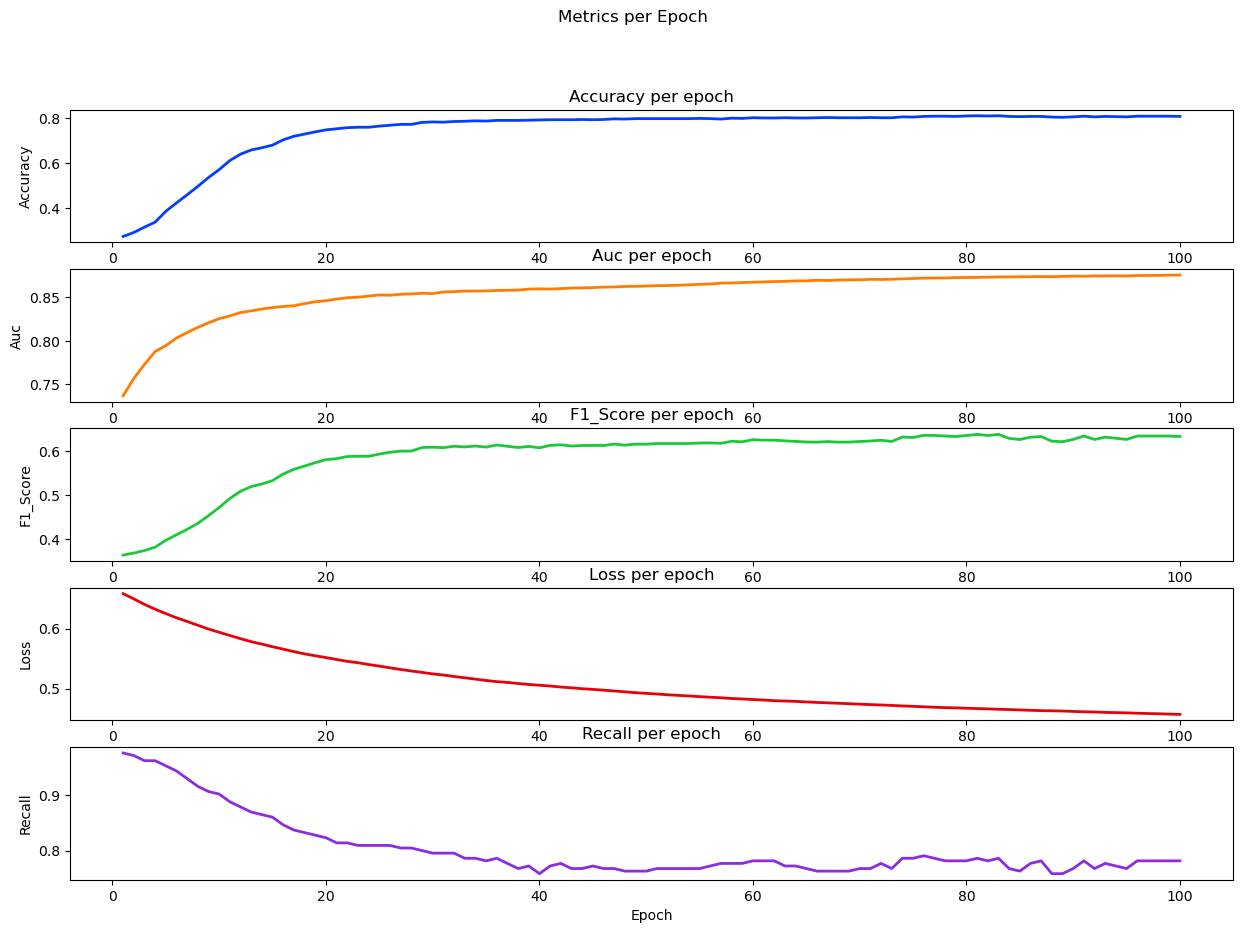

In [13]:
visualize_metrics(baseline_history)

The metrics improve over time as expected

I will now evaluate the model on the train and test set:

In [14]:
# Define a helper function to evaluate a model
def evaluate_model_on_test_and_train(model, X_train=X_train_scaled, y_train=y_train, X_test=X_test_scaled, y_test=y_test):
    print("Train:\n", model.evaluate(X_train, y_train, return_dict=True, verbose=False))
    print("Test:\n", model.evaluate(X_test, y_test, return_dict=True, verbose=False))
    return

evaluate_model_on_test_and_train(baseline_model)

Train:
 {'accuracy': 0.807881772518158, 'auc': 0.8754680156707764, 'f1_score': 0.6327683329582214, 'loss': 0.46920856833457947, 'recall': 0.7813953757286072}
Test:
 {'accuracy': 0.7678160667419434, 'auc': 0.8190360069274902, 'f1_score': 0.5738396048545837, 'loss': 0.5422691702842712, 'recall': 0.739130437374115}


Decent performance. I will now apply regularization to see if it improves performance

### a) l1 regularization

I will use an $ \alpha $ of 0.005

In [15]:
l1_model = models.Sequential()

# Add input layer
l1_model.add(layers.Input(input_shape))

# Add hidden layers with l1 regularization applied
l1_model.add(layers.Dense(50, activation='relu', kernel_regularizer=keras.regularizers.l1(0.005)))
l1_model.add(layers.Dense(25, activation='relu', kernel_regularizer=keras.regularizers.l1(0.005)))

# Add output layer
l1_model.add(layers.Dense(1, activation='sigmoid'))

# Train the model
l1_history = compile_and_fit(l1_model)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7074 - auc: 0.4207 - f1_score: 0.1681 - loss: 1.9907 - recall: 0.1395
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7034 - auc: 0.4680 - f1_score: 0.2016 - loss: 1.9650 - recall: 0.1767 
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7025 - auc: 0.5427 - f1_score: 0.2450 - loss: 1.9399 - recall: 0.2279 
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7094 - auc: 0.6228 - f1_score: 0.3091 - loss: 1.9187 - recall: 0.3070 
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7123 - auc: 0.6872 - f1_score: 0.3707 - loss: 1.9018 - recall: 0.4000 
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7133 - auc: 0.7401 - f1_score: 0.4415 - loss: 1.8862 - recall: 0.5349
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7202 - auc: 0.7768 - f1_score: 0.5018 - loss: 1.8716 - recall: 0.6651
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0

Visualizing metric performance:

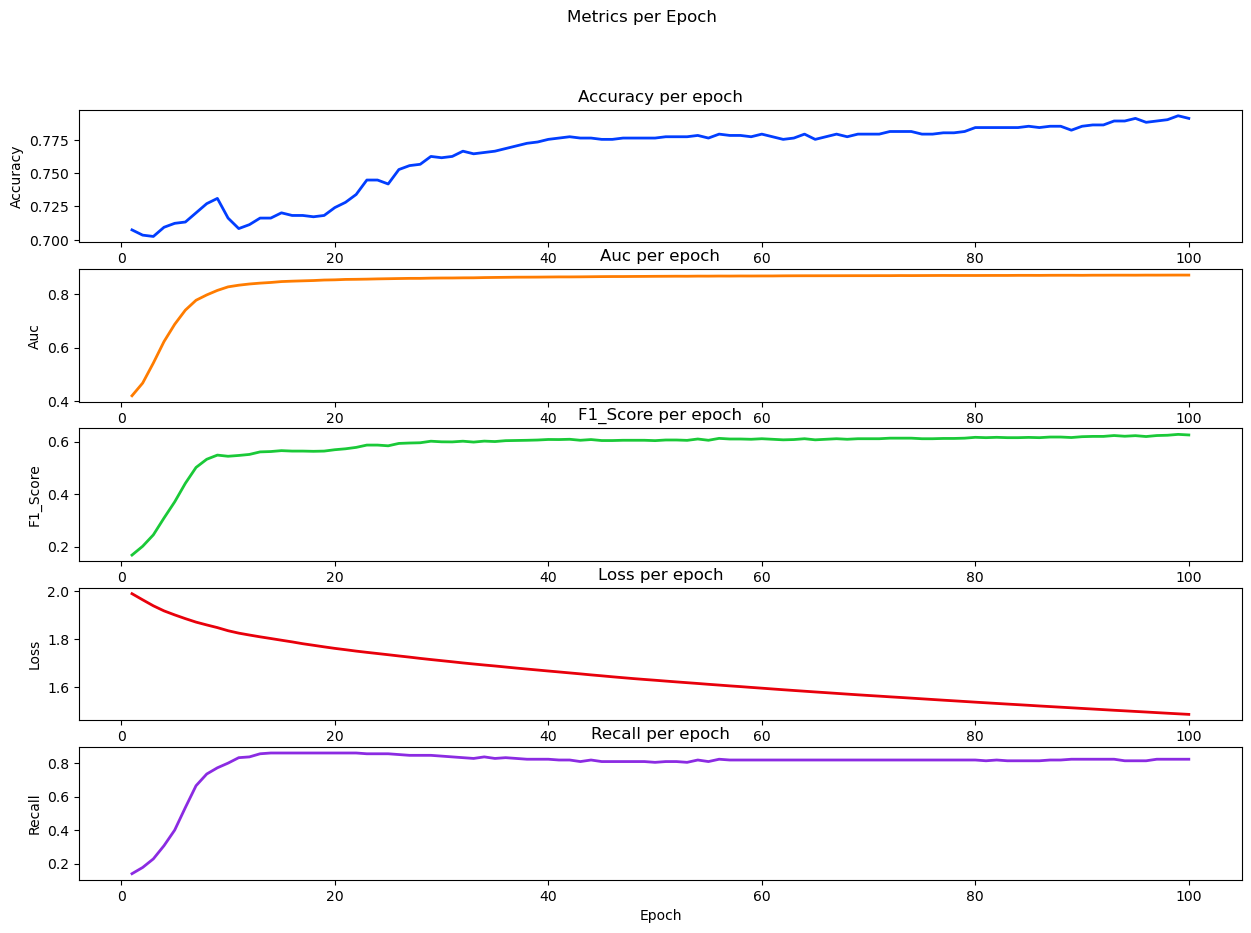

In [16]:
visualize_metrics(l1_history)

The recall appears to be fluctuating.

Evaluating on train and test set:

In [17]:
print("Baseline:")
evaluate_model_on_test_and_train(baseline_model)
print("\n\n")
print("l1 model:")
evaluate_model_on_test_and_train(l1_model)

Baseline:
Train:
 {'accuracy': 0.807881772518158, 'auc': 0.8754680156707764, 'f1_score': 0.6327683329582214, 'loss': 0.46920856833457947, 'recall': 0.7813953757286072}
Test:
 {'accuracy': 0.7678160667419434, 'auc': 0.8190360069274902, 'f1_score': 0.5738396048545837, 'loss': 0.5422691702842712, 'recall': 0.739130437374115}



l1 model:
Train:
 {'accuracy': 0.7911329865455627, 'auc': 0.8709970712661743, 'f1_score': 0.6254416704177856, 'loss': 1.492727518081665, 'recall': 0.8232558369636536}
Test:
 {'accuracy': 0.7678160667419434, 'auc': 0.8242172598838806, 'f1_score': 0.5910930037498474, 'loss': 1.5475088357925415, 'recall': 0.79347825050354}


The l1 model appears to have comparable performance to the baseline (except for probably a much lower recall score)

### b) l2 regularization

In [18]:
l2_model = models.Sequential()

# Add input layer
l2_model.add(layers.Input(input_shape))

# Add hidden layers
l2_model.add(layers.Dense(50, activation='relu', kernel_regularizer=keras.regularizers.l2(0.005)))
l2_model.add(layers.Dense(25, activation='relu', kernel_regularizer=keras.regularizers.l2(0.005)))

# Add output layer
l2_model.add(layers.Dense(1, activation='sigmoid'))

# Compile and fit the model
l2_history = compile_and_fit(l2_model)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5833 - auc: 0.7920 - f1_score: 0.4732 - loss: 0.8601 - recall: 0.8837
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6325 - auc: 0.8100 - f1_score: 0.5007 - loss: 0.8487 - recall: 0.8698
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6680 - auc: 0.8208 - f1_score: 0.5247 - loss: 0.8399 - recall: 0.8651
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6759 - auc: 0.8297 - f1_score: 0.5307 - loss: 0.8302 - recall: 0.8651
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6887 - auc: 0.8370 - f1_score: 0.5447 - loss: 0.8214 - recall: 0.8791
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7034 - auc: 0.8422 - f1_score: 0.5567 - loss: 0.8138 - recall: 0.8791
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7192 - auc: 0.8468 - f1_score: 0.5636 - loss: 0.8067 - recall: 0.8558
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 

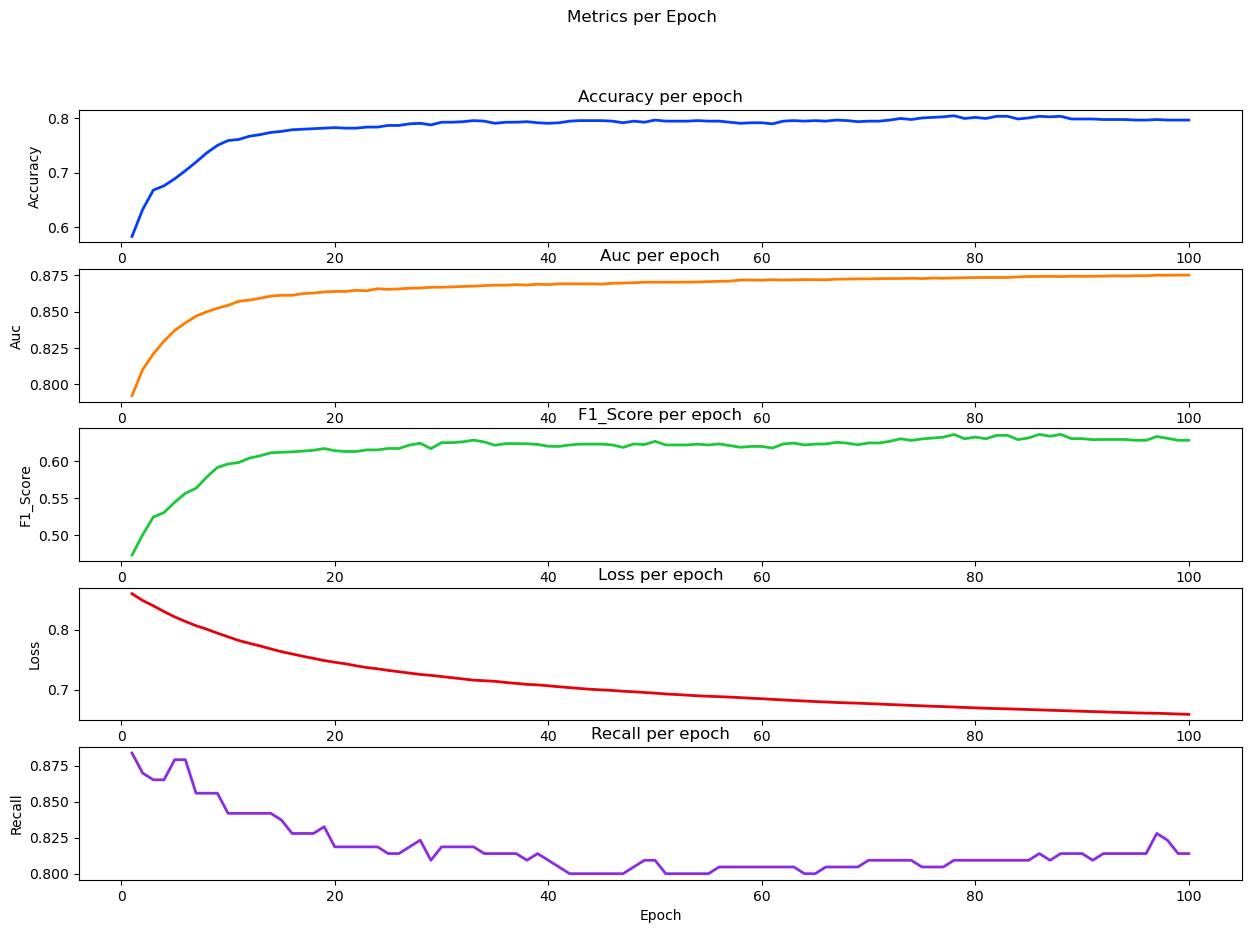

In [19]:
visualize_metrics(l2_history)

In [20]:
print("Baseline:")
evaluate_model_on_test_and_train(baseline_model)
print("\n\n")
print("l1 model:")
evaluate_model_on_test_and_train(l1_model)
print("\n\n")
print("l2 model:")
evaluate_model_on_test_and_train(l2_model)

Baseline:
Train:
 {'accuracy': 0.807881772518158, 'auc': 0.8754680156707764, 'f1_score': 0.6327683329582214, 'loss': 0.46920856833457947, 'recall': 0.7813953757286072}
Test:
 {'accuracy': 0.7678160667419434, 'auc': 0.8190360069274902, 'f1_score': 0.5738396048545837, 'loss': 0.5422691702842712, 'recall': 0.739130437374115}



l1 model:
Train:
 {'accuracy': 0.7911329865455627, 'auc': 0.8709970712661743, 'f1_score': 0.6254416704177856, 'loss': 1.492727518081665, 'recall': 0.8232558369636536}
Test:
 {'accuracy': 0.7678160667419434, 'auc': 0.8242172598838806, 'f1_score': 0.5910930037498474, 'loss': 1.5475088357925415, 'recall': 0.79347825050354}



l2 model:
Train:
 {'accuracy': 0.7960591316223145, 'auc': 0.8751773834228516, 'f1_score': 0.6283661723136902, 'loss': 0.677135169506073, 'recall': 0.8139534592628479}
Test:
 {'accuracy': 0.7655172348022461, 'auc': 0.8249144554138184, 'f1_score': 0.5785123705863953, 'loss': 0.745890200138092, 'recall': 0.760869562625885}


The l2 model has better recall and auc score compared to baseline.

### c) Dropout Regularization

I will use a dropout rate of 0.3

In [22]:
dropout_model = models.Sequential()

# Add input layer
dropout_model.add(layers.Input(input_shape))
## I will not add dropout to the input layer given that the data is not substantive

# Add hidden layers and include dropout. Use a seed for reproducibility
dropout_model.add(layers.Dense(50, activation='relu'))
dropout_model.add(layers.Dropout(0.3, seed=2026))
dropout_model.add(layers.Dense(25, activation='relu'))
dropout_model.add(layers.Dropout(0.3, seed=2026))

# Add output layer
dropout_model.add(layers.Dense(1, activation='sigmoid'))

# Compile and fit the model
dropout_history = compile_and_fit(dropout_model)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6749 - auc: 0.4517 - f1_score: 0.1582 - loss: 0.7781 - recall: 0.1442
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6906 - auc: 0.4565 - f1_score: 0.1604 - loss: 0.7580 - recall: 0.1395
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6818 - auc: 0.4901 - f1_score: 0.2064 - loss: 0.7410 - recall: 0.1953
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6493 - auc: 0.4856 - f1_score: 0.1909 - loss: 0.7328 - recall: 0.1953
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6778 - auc: 0.5649 - f1_score: 0.2652 - loss: 0.7037 - recall: 0.2744
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6788 - auc: 0.5578 - f1_score: 0.2557 - loss: 0.7063 - recall: 0.2605
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6680 - auc: 0.5649 - f1_score: 0.3164 - loss: 0.6971 - recall: 0.3628
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 